# Visualizing Chipotle's Data

This time we are going to pull data directly from the internet.
Special thanks to: https://github.com/justmarkham for sharing the dataset and materials.

### Step 1. Import the necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/thieu1995/csv-files/main/data/pandas/chipotle.tsv).

In [2]:
url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv"

### Step 3. Assign it to a variable called chipo.

In [3]:
chipo = pd.read_csv(url, sep="\t")

### Step 4. See the first 10 entries

In [4]:
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


### Step 5. Create a histogram of the top 5 items bought

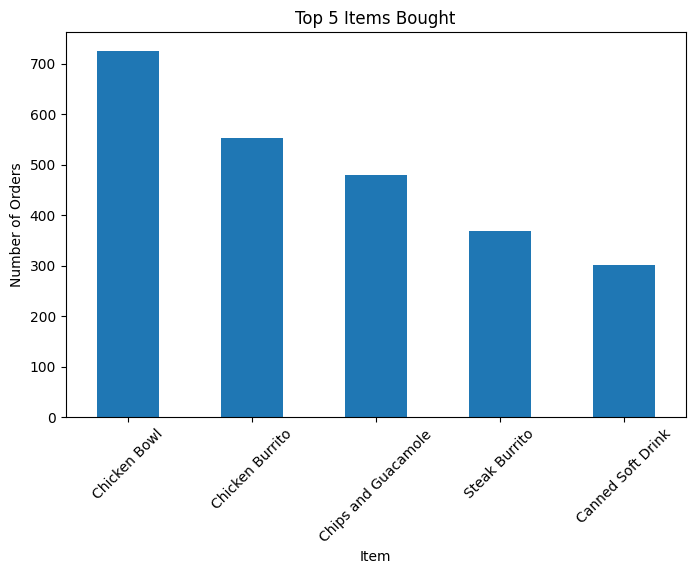

In [5]:
top5 = chipo["item_name"].value_counts().head(5)

plt.figure(figsize=(8,5))
top5.plot(kind="bar")
plt.title("Top 5 Items Bought")
plt.xlabel("Item")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

### Step 6. Create a scatterplot with the number of items orderered per order price
#### Hint: Price should be in the X-axis and Items ordered in the Y-axis

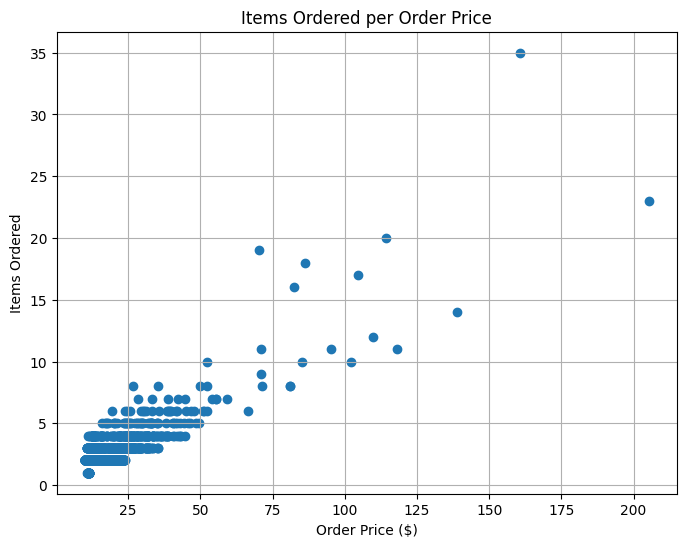

In [6]:

chipo["item_price"] = chipo["item_price"].str.replace("$", "", regex=False).astype(float)
order_price = chipo.groupby("order_id")["item_price"].sum()
items_ordered = chipo.groupby("order_id")["quantity"].sum()

plt.figure(figsize=(8,6))
plt.scatter(order_price, items_ordered)
plt.title("Items Ordered per Order Price")
plt.xlabel("Order Price ($)")
plt.ylabel("Items Ordered")
plt.grid(True)
plt.show()

### Step 7. BONUS: Create a question and a graph to answer your own question.

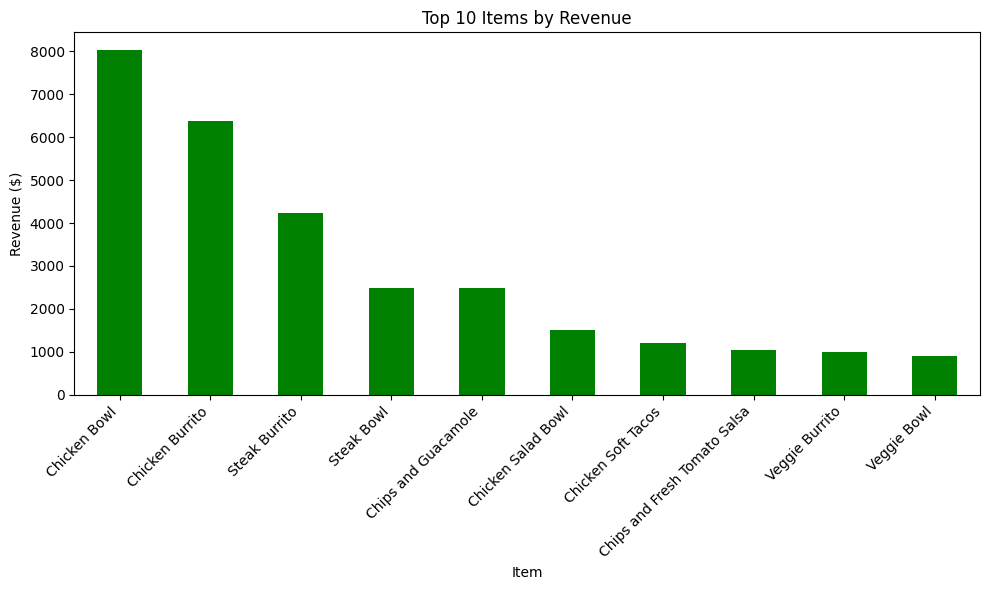

In [7]:

chipo["revenue"] = chipo["quantity"] * chipo["item_price"]

top_revenue = (
    chipo.groupby("item_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_revenue.plot(kind="bar", color="green")
plt.title("Top 10 Items by Revenue")
plt.xlabel("Item")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()